In [28]:
from statsbombpy import sb 
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

In [29]:
competition_id = 11
season_id = 27

matches = sb.matches(
    competition_id=competition_id,
    season_id=season_id
)

# ----------------------------------
# Download events
# ----------------------------------

all_events = []

for match_id in matches.head(100)['match_id']:

    print(f"Downloading {match_id}")

    match_events = sb.events(match_id=match_id)

    all_events.append(match_events)

# ----------------------------------
# Join events
# ----------------------------------

events = pd.concat(
    all_events,
    ignore_index=True
)

# ----------------------------------
# Function
# ----------------------------------

def count_events(df, event_type, column_name):

    return (
        df[df['type'] == event_type]
        .groupby('player')
        .size()
        .reset_index(name=column_name)
    )

# ----------------------------------
# Metrics
# ----------------------------------

passes_by_player = count_events(
    events,
    'Pass',
    'passes'
)

shots_by_player = count_events(
    events,
    'Shot',
    'shots'
)

pressures_by_player = count_events(
    events,
    'Pressure',
    'pressures'
)

recoveries_by_player = count_events(
    events,
    'Ball Recovery',
    'recoveries'
)

# ----------------------------------
# xG
# ----------------------------------

shots = events[
    events['type'] == 'Shot'
]

xg_by_player = (
    shots
    .groupby('player')['shot_statsbomb_xg']
    .sum()
    .reset_index(name='xg')
)

# ----------------------------------
# Master Dataset
# ----------------------------------

player_stats = passes_by_player.copy()

player_stats = player_stats.merge(
    shots_by_player,
    on='player',
    how='outer'
)

player_stats = player_stats.merge(
    xg_by_player,
    on='player',
    how='outer'
)

player_stats = player_stats.merge(
    pressures_by_player,
    on='player',
    how='outer'
)

player_stats = player_stats.merge(
    recoveries_by_player,
    on='player',
    how='outer'
)

player_stats = player_stats.fillna(0)

# ----------------------------------
# Export
# ----------------------------------

#player_stats.to_csv(
#    '../data/interim/player_stats_10_matches.csv',
#    index=False
#)

player_stats.head()


,player,passes,shots,xg,pressures,recoveries
0,Abdoul Karim Yoda,240.0,4.0,0.144908,70.0,27.0
1,Abdoulaye Doucouré,323.0,5.0,0.170600,135.0,55.0
2,Abraham González Casanova,299.0,9.0,1.216896,122.0,31.0
3,Adalberto Peñaranda Maestre,104.0,4.0,0.166700,97.0,21.0
4,Aderllan Leandro de Jesus Santos,243.0,5.0,0.945414,64.0,19.0


In [30]:
player_stats.shape

(436, 6)

In [31]:
player_stats.describe()


,passes,shots,xg,pressures,recoveries
count,436.000000,436.000000,436.000000,436.000000,436.000000
mean,220.522936,5.477064,0.581788,70.309633,23.461009
std,161.119979,6.920695,1.036819,58.373376,18.061093
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,90.750000,1.000000,0.010884,24.000000,9.000000
50%,212.500000,3.000000,0.182570,60.000000,20.000000
75%,318.500000,8.000000,0.671847,102.250000,35.000000
max,884.000000,54.000000,9.046021,273.000000,77.000000


In [32]:
player_stats.sort_values(by='xg', ascending=False).head(10)

,player,passes,shots,xg,pressures,recoveries
74,Cristiano Ronaldo dos Santos Aveiro,258.0,54.0,9.046021,36.0,14.0
417,Youssef El-Arabi,178.0,18.0,6.556074,132.0,31.0
52,Borja González Tomás,235.0,36.0,5.669624,222.0,28.0
38,Aritz Aduriz Zubeldia,164.0,25.0,5.589503,53.0,29.0
252,Kevin Gameiro,135.0,23.0,4.966094,106.0,24.0
109,Duje Čop,280.0,24.0,4.931005,153.0,30.0
349,Rubén Castro Martín,245.0,28.0,4.224943,74.0,20.0
399,Vicente Iborra De La Fuente,215.0,16.0,4.114929,82.0,21.0
132,Francisco Alcácer García,166.0,21.0,3.820189,133.0,16.0
29,Antoine Griezmann,372.0,26.0,3.789528,167.0,49.0


In [33]:
events[
    ['type', 'player', 'minute', 'match_id']
].head(20)

,type,player,minute,match_id
0,Starting XI,NaN,0,3825739
1,Starting XI,NaN,0,3825739
2,Half Start,NaN,0,3825739
3,Half Start,NaN,0,3825739
4,Half Start,NaN,45,3825739
5,Half Start,NaN,45,3825739
6,Pass,Miguel Ángel Guerrero Martín,0,3825739
7,Pass,Alen Halilović,0,3825739
8,Pass,Ignacio Cases Mora,0,3825739
9,Pass,Alejandro Menéndez Díez,0,3825739


In [40]:
events.shape

(340199, 115)

In [34]:
matches_played = (
    events
    .groupby('player')['match_id']
    .nunique()
    .reset_index(name='matches_played')
)
matches_played.head()

,player,matches_played
0,Abdoul Karim Yoda,6
1,Abdoulaye Doucouré,7
2,Abraham González Casanova,9
3,Adalberto Peñaranda Maestre,8
4,Aderllan Leandro de Jesus Santos,6


In [35]:
matches_played['minutes'] = (
    matches_played['matches_played'] * 90
)
matches_played

,player,matches_played,minutes
0,Abdoul Karim Yoda,6,540
1,Abdoulaye Doucouré,7,630
2,Abraham González Casanova,9,810
3,Adalberto Peñaranda Maestre,8,720
4,Aderllan Leandro de Jesus Santos,6,540
...,...,...,...
431,Íñigo Lekue Martínez,7,630
432,Íñigo Martínez Berridi,9,810
433,Óliver Torres Muñoz,5,450
434,Óscar Esau Duarte Gaitán,9,810


In [36]:
player_stats = player_stats.merge(
    matches_played,
    on='player',
    how='left'
)
player_stats.head()

,player,passes,shots,xg,pressures,recoveries,matches_played,minutes
0,Abdoul Karim Yoda,240.0,4.0,0.144908,70.0,27.0,6,540
1,Abdoulaye Doucouré,323.0,5.0,0.170600,135.0,55.0,7,630
2,Abraham González Casanova,299.0,9.0,1.216896,122.0,31.0,9,810
3,Adalberto Peñaranda Maestre,104.0,4.0,0.166700,97.0,21.0,8,720
4,Aderllan Leandro de Jesus Santos,243.0,5.0,0.945414,64.0,19.0,6,540


In [37]:
player_stats['passes_per90'] = (
    player_stats['passes']
    / player_stats['minutes']
) * 90

player_stats['shots_per90'] = (
    player_stats['shots']
    / player_stats['minutes']
) * 90

player_stats['shots_per90'] = (
    player_stats['shots']
    / player_stats['minutes']
) * 90

player_stats['xg_per90'] = (
    player_stats['xg']
    / player_stats['minutes']
) * 90

player_stats['pressures_per90'] = (
    player_stats['pressures']
    / player_stats['minutes']
) * 90

player_stats['recoveries_per90'] = (
    player_stats['recoveries']
    / player_stats['minutes']
) * 90

player_stats = player_stats.round(2)

player_stats.sort_values(
    by='xg_per90',
    ascending=False
).head(10)


,player,passes,shots,xg,pressures,recoveries,matches_played,minutes,passes_per90,shots_per90,xg_per90,pressures_per90,recoveries_per90
74,Cristiano Ronaldo dos Santos Aveiro,258.0,54.0,9.05,36.0,14.0,8,720,32.25,6.75,1.13,4.50,1.75
417,Youssef El-Arabi,178.0,18.0,6.56,132.0,31.0,8,720,22.25,2.25,0.82,16.50,3.88
38,Aritz Aduriz Zubeldia,164.0,25.0,5.59,53.0,29.0,8,720,20.50,3.12,0.70,6.62,3.63
187,Javier Guerra Rodríguez,102.0,18.0,2.82,82.0,16.0,5,450,20.40,3.60,0.56,16.40,3.20
252,Kevin Gameiro,135.0,23.0,4.97,106.0,24.0,9,810,15.00,2.56,0.55,11.78,2.67
251,Karim Benzema,184.0,20.0,2.91,38.0,13.0,6,540,30.67,3.33,0.49,6.33,2.17
52,Borja González Tomás,235.0,36.0,5.67,222.0,28.0,12,1080,19.58,3.00,0.47,18.50,2.33
349,Rubén Castro Martín,245.0,28.0,4.22,74.0,20.0,9,810,27.22,3.11,0.47,8.22,2.22
143,Gareth Frank Bale,154.0,12.0,1.85,22.0,13.0,4,360,38.50,3.00,0.46,5.50,3.25
109,Duje Čop,280.0,24.0,4.93,153.0,30.0,11,990,25.45,2.18,0.45,13.91,2.73


In [38]:
player_stats = player_stats[
    player_stats['matches_played'] >= 3
]

player_stats.shape

(367, 13)

In [42]:
player_stats['xg_per_shot'] = (
    player_stats['xg']
    /
    player_stats['shots'].replace(0, np.nan)
)

player_stats.head()

,player,passes,shots,xg,pressures,recoveries,matches_played,minutes,passes_per90,shots_per90,xg_per90,pressures_per90,recoveries_per90,xg_per_shot
0,Abdoul Karim Yoda,240.0,4.0,0.14,70.0,27.0,6,540,40.00,0.67,0.02,11.67,4.50,0.035000
1,Abdoulaye Doucouré,323.0,5.0,0.17,135.0,55.0,7,630,46.14,0.71,0.02,19.29,7.86,0.034000
2,Abraham González Casanova,299.0,9.0,1.22,122.0,31.0,9,810,33.22,1.00,0.14,13.56,3.44,0.135556
3,Adalberto Peñaranda Maestre,104.0,4.0,0.17,97.0,21.0,8,720,13.00,0.50,0.02,12.12,2.62,0.042500
4,Aderllan Leandro de Jesus Santos,243.0,5.0,0.95,64.0,19.0,6,540,40.50,0.83,0.16,10.67,3.17,0.190000


In [44]:
player_stats['pressure_pass_ratio'] = (
    player_stats['pressures']
    /
    player_stats['passes'].replace(0, np.nan)
)
player_stats.head()

,player,passes,shots,xg,pressures,recoveries,matches_played,minutes,passes_per90,shots_per90,xg_per90,pressures_per90,recoveries_per90,xg_per_shot,pressure_pass_ratio
0,Abdoul Karim Yoda,240.0,4.0,0.14,70.0,27.0,6,540,40.00,0.67,0.02,11.67,4.50,0.035000,0.291667
1,Abdoulaye Doucouré,323.0,5.0,0.17,135.0,55.0,7,630,46.14,0.71,0.02,19.29,7.86,0.034000,0.417957
2,Abraham González Casanova,299.0,9.0,1.22,122.0,31.0,9,810,33.22,1.00,0.14,13.56,3.44,0.135556,0.408027
3,Adalberto Peñaranda Maestre,104.0,4.0,0.17,97.0,21.0,8,720,13.00,0.50,0.02,12.12,2.62,0.042500,0.932692
4,Aderllan Leandro de Jesus Santos,243.0,5.0,0.95,64.0,19.0,6,540,40.50,0.83,0.16,10.67,3.17,0.190000,0.263374


In [50]:
player_stats['attacking_score'] = (
    player_stats['xg_per90'] * 0.5 +
    player_stats['shots_per90'] * 0.3 +
    player_stats['passes_per90'] * 0.2
)
player_stats

,player,passes,shots,xg,pressures,recoveries,matches_played,minutes,passes_per90,shots_per90,xg_per90,pressures_per90,recoveries_per90,xg_per_shot,pressure_pass_ratio,attacking_score
0,Abdoul Karim Yoda,240.0,4.0,0.14,70.0,27.0,6,540,40.00,0.67,0.02,11.67,4.50,0.035000,0.291667,8.211
1,Abdoulaye Doucouré,323.0,5.0,0.17,135.0,55.0,7,630,46.14,0.71,0.02,19.29,7.86,0.034000,0.417957,9.451
2,Abraham González Casanova,299.0,9.0,1.22,122.0,31.0,9,810,33.22,1.00,0.14,13.56,3.44,0.135556,0.408027,7.014
3,Adalberto Peñaranda Maestre,104.0,4.0,0.17,97.0,21.0,8,720,13.00,0.50,0.02,12.12,2.62,0.042500,0.932692,2.760
4,Aderllan Leandro de Jesus Santos,243.0,5.0,0.95,64.0,19.0,6,540,40.50,0.83,0.16,10.67,3.17,0.190000,0.263374,8.429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,Íñigo Lekue Martínez,269.0,6.0,0.27,85.0,33.0,7,630,38.43,0.86,0.04,12.14,4.71,0.045000,0.315985,7.964
432,Íñigo Martínez Berridi,437.0,7.0,0.38,74.0,53.0,9,810,48.56,0.78,0.04,8.22,5.89,0.054286,0.169336,9.966
433,Óliver Torres Muñoz,71.0,2.0,0.04,27.0,7.0,5,450,14.20,0.40,0.01,5.40,1.40,0.020000,0.380282,2.965
434,Óscar Esau Duarte Gaitán,294.0,2.0,0.12,71.0,31.0,9,810,32.67,0.22,0.01,7.89,3.44,0.060000,0.241497,6.605


In [47]:
player_stats.sort_values(
    by='attacking_score',
    ascending=False
)[
    [
        'player',
        'attacking_score',
        'xg_per90',
        'shots_per90',
        'passes_per90'
    ]
].head(20)

,player,attacking_score,xg_per90,shots_per90,passes_per90
343,Roberto Trashorras Gayoso,18.370,0.01,0.33,91.33
266,Luka Modrić,16.320,0.04,1.00,80.00
88,Danilo Luiz da Silva,16.049,0.03,1.00,78.67
275,Marcelo Vieira da Silva Júnior,15.998,0.03,0.83,78.67
396,Toni Kroos,15.531,0.01,0.50,76.88
216,Jorge Resurrección Merodio,15.144,0.07,1.25,73.67
79,Daniel Carvajal Ramos,15.051,0.00,0.17,75.00
347,Roque Mesa Quevedo,14.745,0.04,0.75,72.50
375,Sergio Ramos García,13.480,0.01,0.25,67.00
142,Gabriel Fernández Arenas,13.218,0.00,0.18,65.82


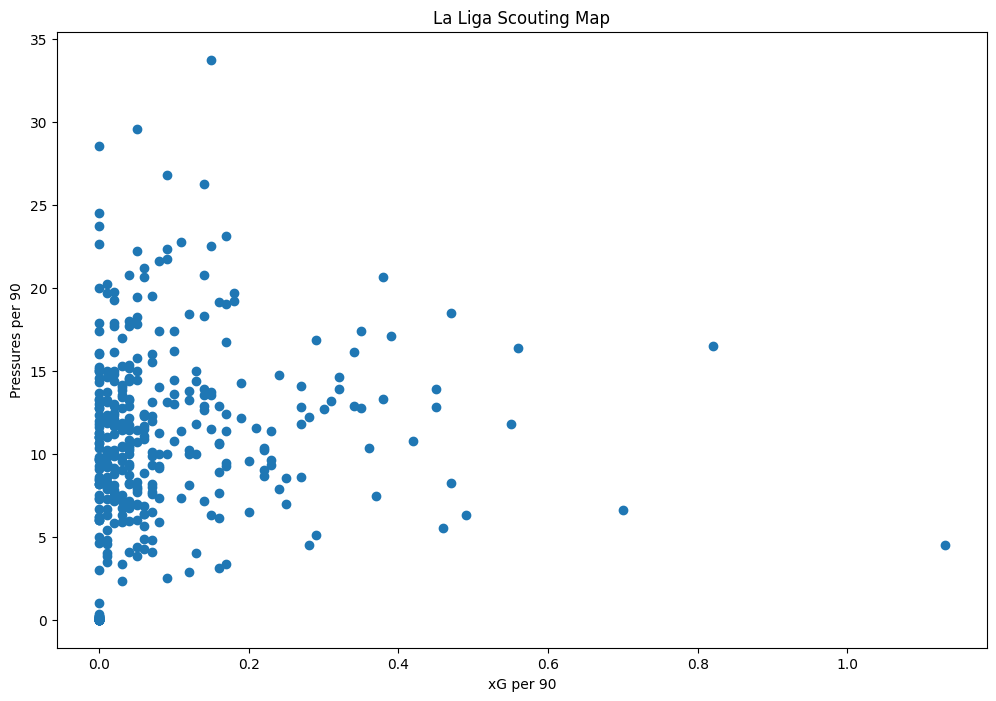

In [48]:
plt.figure(figsize=(12,8))

plt.scatter(
    player_stats['xg_per90'],
    player_stats['pressures_per90']
)

plt.xlabel('xG per 90')
plt.ylabel('Pressures per 90')
plt.title('La Liga Scouting Map')

plt.show()

In [49]:
player_stats.to_csv(
    '../data/cleaned/player_stats_v2.csv',
    index=False
)